In [116]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd
import numpy as np
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys

# Append custom toolbox to the path
sys.path.append('../../mhw3d-detection/src/mhw3d/')
import bipolarMhwToolBox as MHW


%matplotlib inline

In [34]:
def plotmap(data, ax=None):
    """
    Plots a simple Cartopy map with land in grey. The map extent is derived 
    from the provided dataset's latitude and longitude coordinates.

    Parameters
    ----------
    data : xarray.DataArray or xarray.Dataset
        Data containing lat and lon coordinates. Must have data.lat and data.lon
        that can be used to determine the spatial extent.
    ax : matplotlib.axes.Axes or None, optional
        The axes object on which to plot. If None, a new figure and axes are created.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes object containing the plot.
    """
    # Extract min/max lat/lon from the data
    min_lat = float(data.lat.min())
    max_lat = float(data.lat.max())
    min_lon = float(data.lon.min())
    max_lon = float(data.lon.max())

    # Create a new figure and axis if none is provided
    if ax is None:
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        # Ensure the provided axis uses Plate Carree projection
        if not isinstance(ax.projection, ccrs.PlateCarree):
            raise ValueError("The provided axis must have a Plate Carree projection.")

    # Add land in grey
    ax.add_feature(cfeature.LAND, facecolor='grey')

    # Add features to the map
    ax.coastlines(resolution='10m', linewidth=1)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Set the extent from the data
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    return ax

### open datasets

In [106]:
ds = xr.open_dataset('../data/WA_OISST_1989_2018.nc')
clim = xr.open_dataset('../data/clim_thresh_1989_2018_baseline.nc')
sev = xr.open_dataset('../data/WA_OISST_severity_1989_2018.nc')

In [107]:
sev

<xarray.Dataset>
Dimensions:   (time: 10958, zlev: 1, lat: 64, lon: 60)
Coordinates:
  * lat       (lat) float32 -35.88 -35.62 -35.38 -35.12 ... -20.62 -20.38 -20.12
  * lon       (lon) float32 105.1 105.4 105.6 105.9 ... 119.1 119.4 119.6 119.9
  * time      (time) datetime64[ns] 1988-01-01T12:00:00 ... 2017-12-31T12:00:00
  * zlev      (zlev) float32 0.0
Data variables:
    severity  (time, zlev, lat, lon) float32 ...
    ssta      (time, zlev, lat, lon) float32 ...

### prepare data for plotting

In [108]:
day = '2011-03-01'
lat_s = -28
lon_s = 113.8
sst_day = ds.sst.sel(time=day)
tseries = ds.sst.sel(lat=lat_s,lon=lon_s,method='nearest').sel(time=slice('2010-07-01','2011-12-31'))
sev_t = sev.sel(lat=lat_s,lon=lon_s,method='nearest').sel(time=slice('2010-07-01','2011-12-31'))
# Site climatology and threshold from dayofyear dataset
clim_site = clim['clim'].sel(
    lat=lat_s, lon=lon_s, method='nearest'
).squeeze(drop=True)

thresh_site = clim['thresh'].sel(
    lat=lat_s, lon=lon_s, method='nearest'
).squeeze(drop=True)

doy = tseries.time.dt.dayofyear

clim_t = xr.DataArray(
    clim_site.sel(dayofyear=doy).values,
    coords={'time': tseries.time},
    dims=['time'],
    name='clim'
)

thresh_t = xr.DataArray(
    thresh_site.sel(dayofyear=doy).values,
    coords={'time': tseries.time},
    dims=['time'],
    name='thresh'
)

tseries, clim_t, thresh_t = xr.align(tseries, clim_t, thresh_t)

### calculate MHW stats

In [110]:
sev_t

<xarray.Dataset>
Dimensions:   (time: 549, zlev: 1)
Coordinates:
    lat       float32 -27.88
    lon       float32 113.9
  * time      (time) datetime64[ns] 2010-07-01T12:00:00 ... 2011-12-31T12:00:00
  * zlev      (zlev) float32 0.0
Data variables:
    severity  (time, zlev) float32 ...
    ssta      (time, zlev) float32 ...

In [117]:
mhw_stats = MHW.calculate_MHWs_metrics(sev_t,maxEvt=15)

stats = mhw_stats.squeeze('zlev', drop=True)

# index of longest event
iev = stats['duration'].argmax(dim='event').item()

dur = int(stats['duration'].isel(event=iev).item())
imax = stats['intensity_max'].isel(event=iev).item()
imean = stats['intensity_mean'].isel(event=iev).item()
icum = stats['intensity_cumul'].isel(event=iev).item()

dstart = stats['date_start'].isel(event=iev).item()
dend   = stats['date_end'].isel(event=iev).item()
dpeak  = stats['date_peak'].isel(event=iev).item()

# sort out formatting

txt = (
    "Longest MHW\n"
    f"Start: {pd.to_datetime(dstart):%Y-%m-%d}\n"
    f"End:   {pd.to_datetime(dend):%Y-%m-%d}\n"
    f"Peak:  {pd.to_datetime(dpeak):%Y-%m-%d}\n"
    f"Dur:   {dur} d\n"
    f"Imax:  {imax:.2f} °C\n"
    f"Imean: {imean:.2f} °C\n"
    f"Icum:  {icum:.2f} °C·d"
)

### plot

In [98]:
def add_row_dot(fig, subplot_spec, x, color, size=120, dot_size=0.02):
    ss = subplot_spec.get_position(fig)
    y = 0.5 * (ss.y0 + ss.y1)
    ax_dot = fig.add_axes([x, y - dot_size/2, dot_size, dot_size])
    ax_dot.scatter(
    0.5, 0.5,
    s=200,
    color=color,          # fill
    edgecolor='black',    # border
    linewidth=1.0
)
    ax_dot.set_axis_off()
    return ax_dot

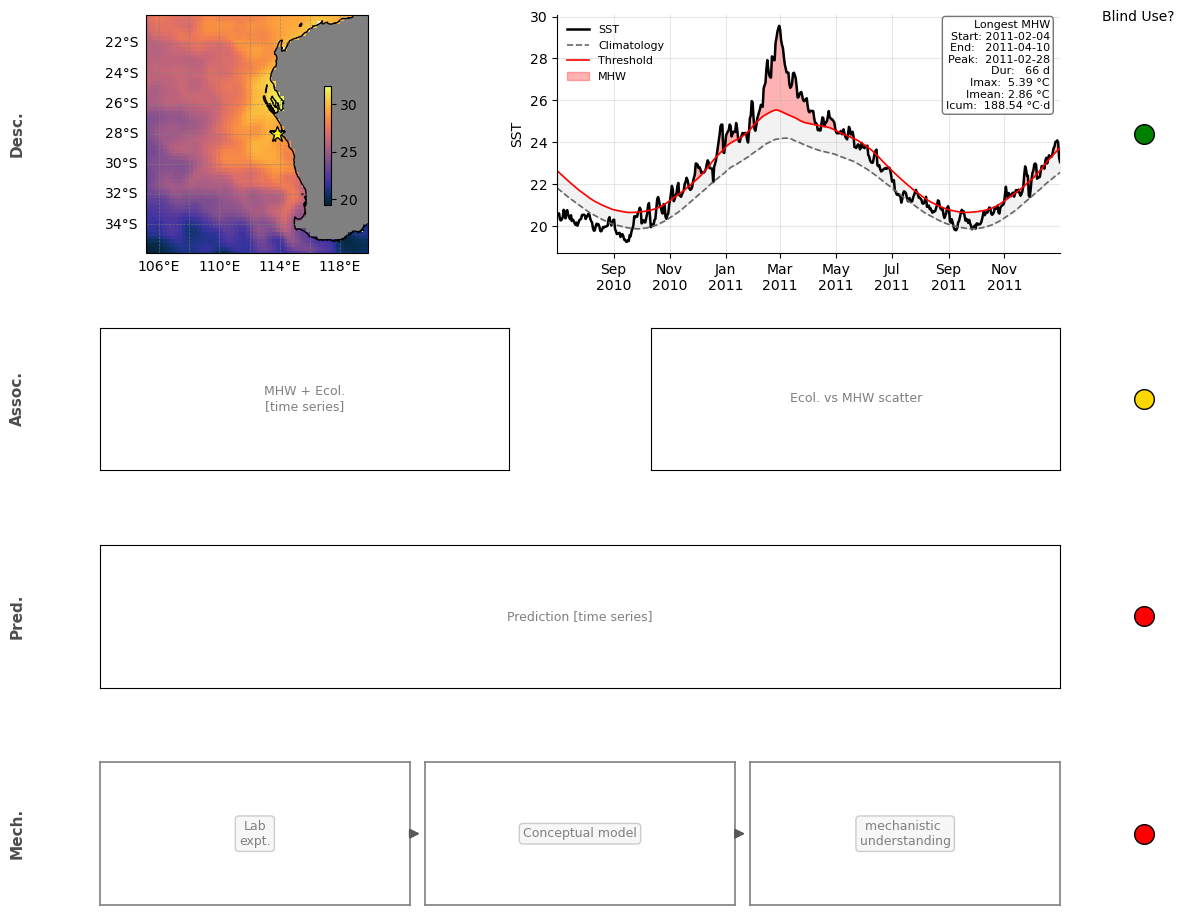

In [123]:
fig = plt.figure(figsize=(12, 10))

# ── Top-level GridSpec: 4 rows ──────────────────────────────────────────────
# Row heights: Desc, Assoc, Pred, Mech
gs_main = gridspec.GridSpec(
    4, 1,
    figure=fig,
    hspace=0.45,
    height_ratios=[2.5, 1.5, 1.5, 1.5],
    left=0.08, right=0.88, top=0.93, bottom=0.04,
)

# ── Row 0: Desc ─────────────────────────────────────────────────────────────
gs_desc = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_main[0], wspace=0.35, width_ratios=[1, 1.6]
)

# spatial map of SST anomaly -----------------------------------------
ax_map = fig.add_subplot(gs_desc[0], projection=ccrs.PlateCarree())
plotmap(ds,ax=ax_map)

# Plot WITHOUT automatic colorbar
p = sst_day.plot(
    ax=ax_map,
    transform=ccrs.PlateCarree(),
    cmap=cmo.thermal,
    add_colorbar=False
)
ax_map.set_xlabel('')
ax_map.set_ylabel('')
ax_map.set_title('')

ax_map.plot(
    lon_s, lat_s,
    marker='*',
    markersize=12,
    markeredgecolor='black',
    markerfacecolor='yellow',
    transform=ccrs.PlateCarree()
)

# inset colorbar: [left, bottom, width, height] in axes coordinates
cax = ax_map.inset_axes([0.8, 0.2, 0.03, 0.5])

cb = fig.colorbar(p, cax=cax)
cb.set_label('')

# Draw colorbar
cb = plt.colorbar(p, cax=cax)
cb.set_label('')  # optional: remove label

# MHW timeseries plot --------------------------------------------------

ax_ts0   = fig.add_subplot(gs_desc[1])   # time series
time = tseries.time.values
sst = tseries.values
clm = clim_t.values
thr = thresh_t.values

# Main lines
ax_ts0.plot(time, sst, color='k', lw=1.8, label='SST')
ax_ts0.plot(time, clm, color='0.4', lw=1.2, ls='--', label='Climatology')
ax_ts0.plot(time, thr, color='r', lw=1.2, label='Threshold')

# Shade MHW periods
ax_ts0.fill_between(
    time, thr, sst,
    where=(sst > thr),
    interpolate=True,
    color='r',
    alpha=0.3,
    label='MHW'
)

# Optional: shade the climatology-to-threshold band
ax_ts0.fill_between(
    time, clm, thr,
    color='0.8',
    alpha=0.25
)

# Cosmetics
ax_ts0.grid(True, alpha=0.3)
ax_ts0.spines['top'].set_visible(False)
ax_ts0.spines['right'].set_visible(False)
ax_ts0.set_title('')
ax_ts0.set_xlabel('')
ax_ts0.set_ylabel('SST')
ax_ts0.legend(frameon=False, fontsize=8, loc='upper left')
ax_ts0.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax_ts0.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax_ts0.set_xlim(tseries.time.min().values,
                tseries.time.max().values)

#plot stats in inset
ax_ts0.text(
    0.98, 0.98, txt,
    transform=ax_ts0.transAxes,
    ha='right', va='top',
    fontsize=8,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.4', alpha=0.9)
)

# ── Row 1: Assoc ─────────────────────────────────────────────────────────────
gs_assoc = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs_main[1], wspace=0.35
)
ax_assoc_ts  = fig.add_subplot(gs_assoc[0])   # MHW + Ecol time series
ax_assoc_xy  = fig.add_subplot(gs_assoc[1])   # Ecol vs MHW (scatter / series)

# ── Row 2: Pred ─────────────────────────────────────────────────────────────
ax_pred = fig.add_subplot(gs_main[2])          # wide prediction time series

# ── Row 3: Mech ─────────────────────────────────────────────────────────────
gs_mech = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_main[3], wspace=0.05
)
ax_lab  = fig.add_subplot(gs_mech[0])   # Lab exp
ax_mod  = fig.add_subplot(gs_mech[1])   # Concept/Mod/Dec
ax_metn = fig.add_subplot(gs_mech[2])   # Metn?

# ── Small legend panel (top right, outside main grid) ───────────────────────
ax_legend = fig.add_axes([0.90, 0.78, 0.09, 0.14])

# ── Row labels ───────────────────────────────────────────────────────────────
row_labels = {
    gs_main[0]: "Desc.",
    gs_main[1]: "Assoc.",
    gs_main[2]: "Pred.",
    gs_main[3]: "Mech.",
}
label_x = 0.005
for gs_row, label in row_labels.items():
    # Get the vertical centre of the subplot spec in figure coordinates
    ss = gs_row.get_position(fig)
    y_centre = (ss.y0 + ss.y1) / 2
    fig.text(label_x, y_centre, label,
             va="center", ha="left",
             fontsize=11, fontweight="bold",
             rotation=90, color="0.3")

# ── Mech arrows (drawn in figure coords between the three boxes) ─────────────
for ax_src, ax_dst in [(ax_lab, ax_mod), (ax_mod, ax_metn)]:
    p_src = ax_src.get_position()
    p_dst = ax_dst.get_position()
    x_start = p_src.x1
    x_end   = p_dst.x0
    y_mid   = (p_src.y0 + p_src.y1) / 2
    arrow = FancyArrowPatch(
        (x_start + 0.002, y_mid), (x_end - 0.002, y_mid),
        transform=fig.transFigure,
        arrowstyle="-|>",
        mutation_scale=14,
        color="0.35",
        linewidth=1.5,
        clip_on=False,
    )
    fig.add_artist(arrow)
    
# -- Add blind use traffic light dots -----------------
add_row_dot(fig, gs_main[0], 0.94, 'green')
add_row_dot(fig, gs_main[1], 0.94, 'gold')
add_row_dot(fig, gs_main[2], 0.94, 'red')
add_row_dot(fig, gs_main[3], 0.94, 'red')

# ── Cosmetic: placeholder labels on every axis ───────────────────────────────
axes_labels = {
    #ax_map:       ("SST / MHW\n[map]",   False),
    #ax_ts0:       ("MHW\n[time series]", False),
    ax_assoc_ts:  ("MHW + Ecol.\n[time series]", False),
    ax_assoc_xy:  ("Ecol. vs MHW scatter", False),
    ax_pred:      ("Prediction [time series]", False),
    ax_lab:       ("Lab\nexpt.", True),
    ax_mod:       ("Conceptual model", True),
    ax_metn:      ("mechanistic \nunderstanding" , True),
    ax_legend:    ("", False),
}

for ax, (label, box) in axes_labels.items():
    ax.text(0.5, 0.5, label,
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=9, color="0.5",
            bbox=dict(boxstyle="round,pad=0.3", fc="0.97", ec="0.8") if box else None)
    if box:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_edgecolor("0.5")
    ax.set_xticks([])
    ax.set_yticks([])

ax_legend.set_title("Blind Use?", fontsize=10, pad=3)
for spine in ax_legend.spines.values():
    spine.set_visible(False)

fig.suptitle("",
             fontsize=14, color="0.4", y=0.97)

plt.savefig("../plots/MHW_ID_hierarchy.png", dpi=150, bbox_inches="tight")
#plt.savefig("/mnt/user-data/outputs/figure_layout.pdf", bbox_inches="tight")